In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier,AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb
from sklearn.metrics import accuracy_score,classification_report

In [3]:
df=pd.read_csv('credi bill payments.csv')
df.head()

,LIMIT_BAL,GENDER,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   LIMIT_BAL                   30000 non-null  int64
 1   GENDER                      30000 non-null  int64
 2   EDUCATION                   30000 non-null  int64
 3   MARRIAGE                    30000 non-null  int64
 4   AGE                         30000 non-null  int64
 5   PAY_0                       30000 non-null  int64
 6   PAY_2                       30000 non-null  int64
 7   PAY_3                       30000 non-null  int64
 8   PAY_4                       30000 non-null  int64
 9   PAY_5                       30000 non-null  int64
 10  PAY_6                       30000 non-null  int64
 11  BILL_AMT1                   30000 non-null  int64
 12  BILL_AMT2                   30000 non-null  int64
 13  BILL_AMT3                   30000 non-null  int64
 14  BILL_AMT4        

In [5]:
df.dtypes

LIMIT_BAL                     int64
GENDER                        int64
EDUCATION                     int64
MARRIAGE                      int64
AGE                           int64
PAY_0                         int64
PAY_2                         int64
PAY_3                         int64
PAY_4                         int64
PAY_5                         int64
PAY_6                         int64
BILL_AMT1                     int64
BILL_AMT2                     int64
BILL_AMT3                     int64
BILL_AMT4                     int64
BILL_AMT5                     int64
BILL_AMT6                     int64
PAY_AMT1                      int64
PAY_AMT2                      int64
PAY_AMT3                      int64
PAY_AMT4                      int64
PAY_AMT5                      int64
PAY_AMT6                      int64
default payment next month    int64
dtype: object

In [6]:
df.shape

(30000, 24)

In [7]:
df.columns

Index(['LIMIT_BAL', 'GENDER', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='str')

In [8]:
df.isnull().sum()

LIMIT_BAL                     0
GENDER                        0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default payment next month    0
dtype: int64

In [9]:
df['default payment next month'].value_counts()

default payment next month
0    23364
1     6636
Name: count, dtype: int64

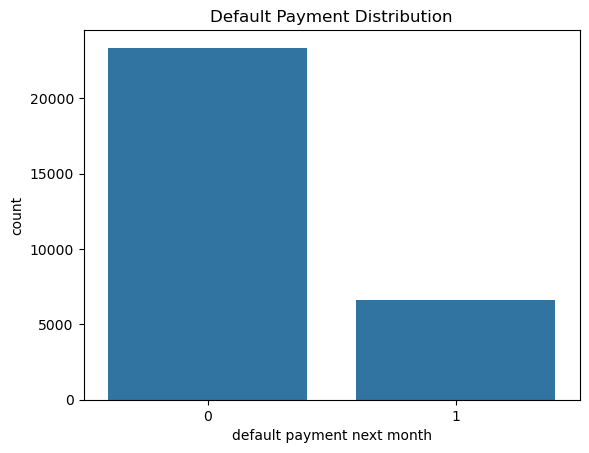

In [10]:
sns.countplot(x='default payment next month', data=df)
plt.title("Default Payment Distribution")
plt.show()

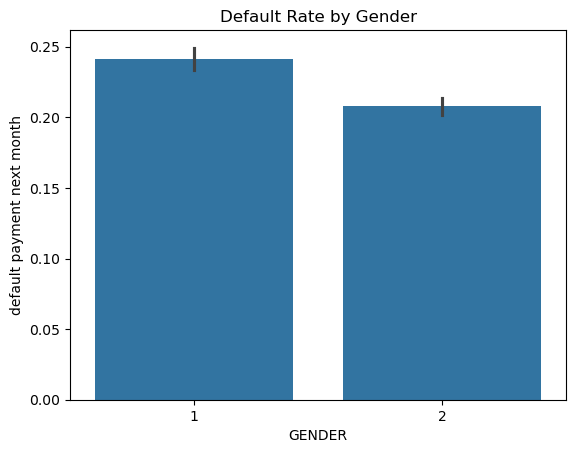

In [11]:
#a. default payment next month rate by gender 
sns.barplot(x='GENDER', y='default payment next month', data=df)
plt.title("Default Rate by Gender")
plt.show()

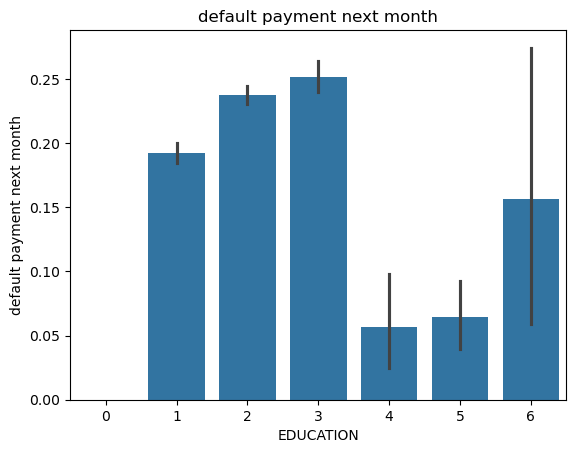

In [12]:
#b. default payment next month by education 
sns.barplot(x='EDUCATION',y='default payment next month',data=df)
plt.title("default payment next month")
plt.show()

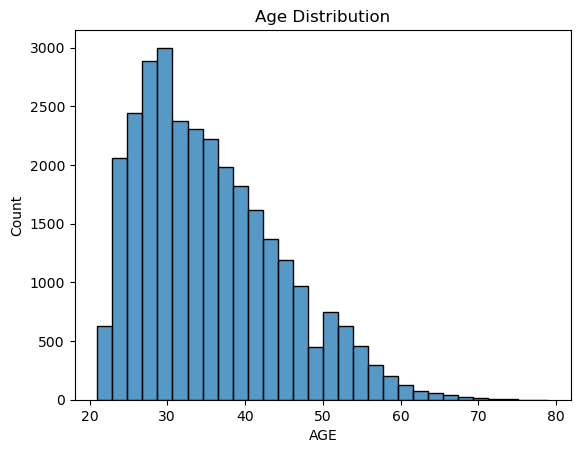

In [13]:
#c. Age distribution 
sns.histplot(df['AGE'],bins=30)
plt.title("Age Distribution")
plt.show()

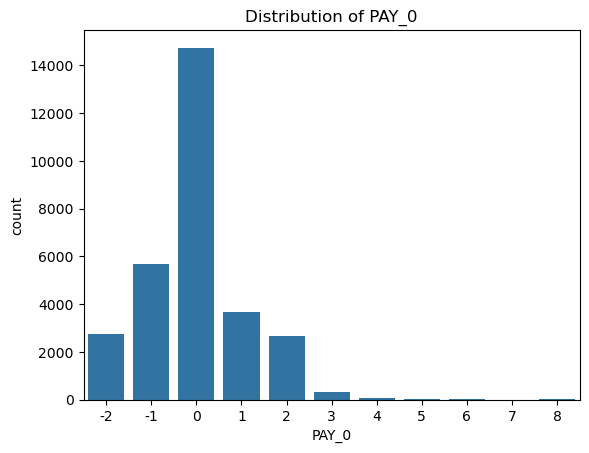

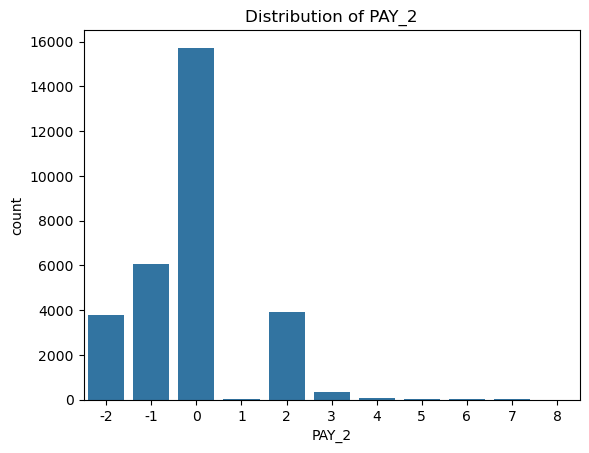

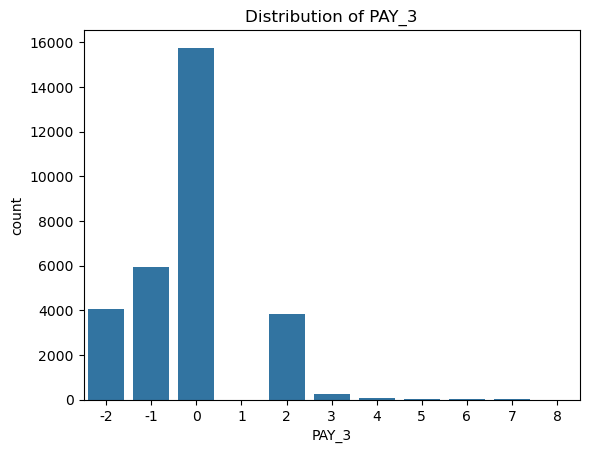

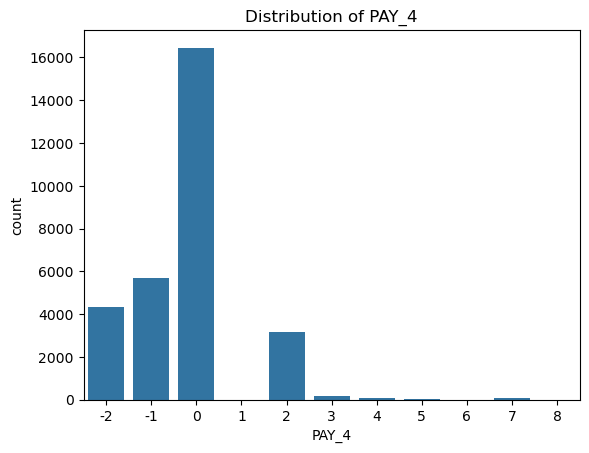

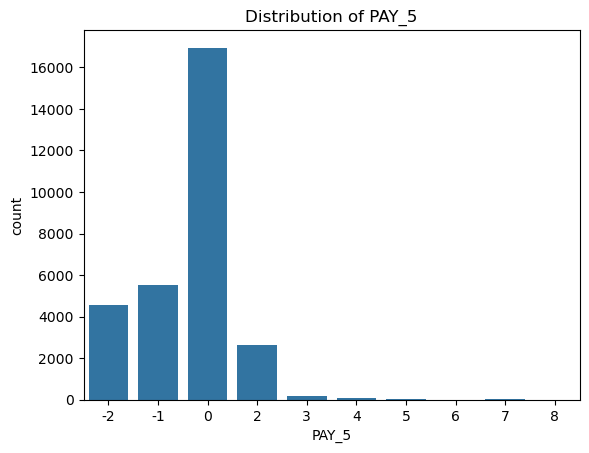

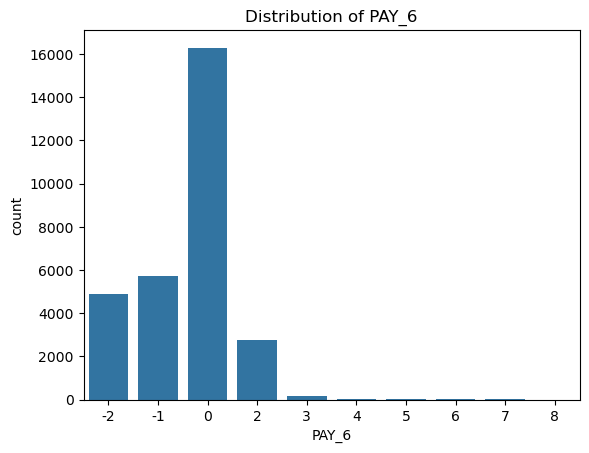

In [14]:
#d. Payment delay distribution

pay_cols=['PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

for col in pay_cols:
    sns.countplot(x=col,data=df)
    plt.title(f"Distribution of {col}")
    plt.show()

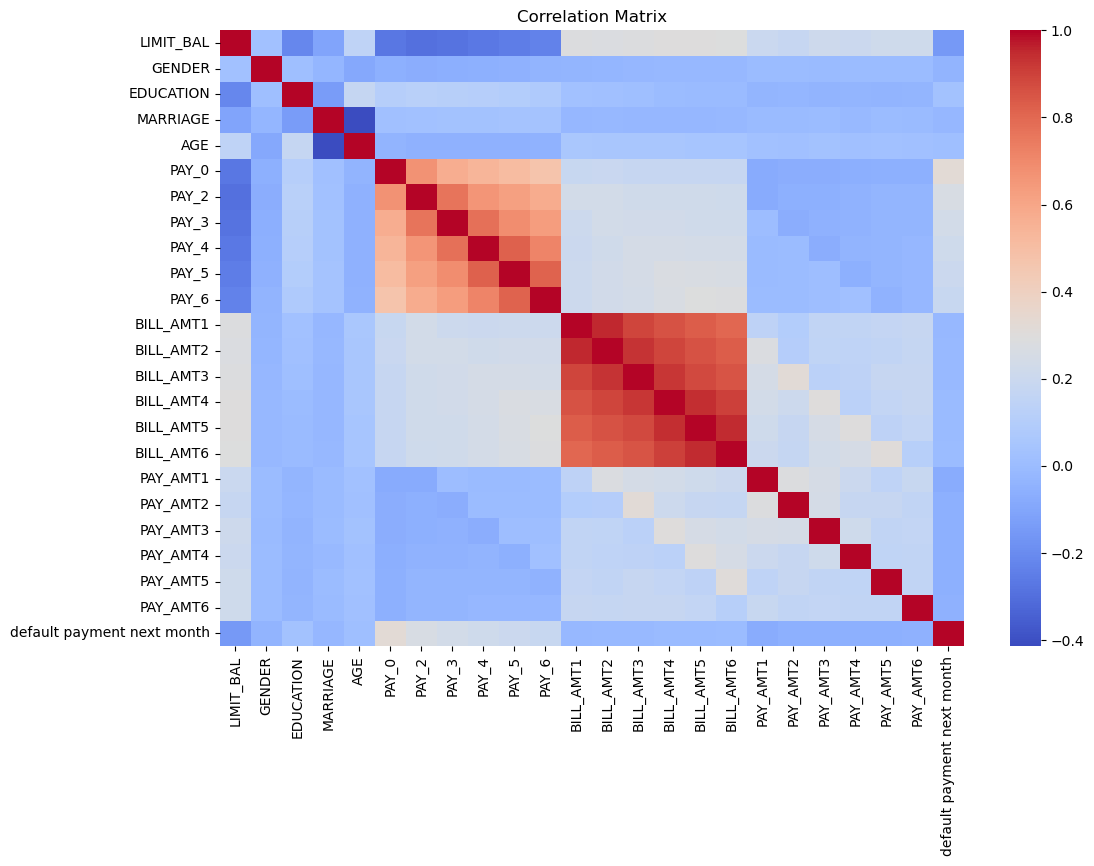

In [15]:
#5. Correlation analysis 

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [16]:
#find any invalid values
df['EDUCATION'].unique()

array([2, 1, 3, 5, 4, 6, 0], dtype=int64)

In [17]:
df['MARRIAGE'].unique()

array([1, 2, 3, 0], dtype=int64)

In [18]:
#handle invalid values
df['EDUCATION'] = df['EDUCATION'].replace([0,5,6],4)

df['MARRIAGE'] = df['MARRIAGE'].replace(0,3)

In [19]:
X=df.drop('default payment next month',axis=1)
y= df['default payment next month']

In [20]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(
    X,y, test_size = 0.2,random_state =42)

In [21]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [22]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

In [24]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [25]:
def evaluate_model(model,X_train,X_test,y_train,y_test):
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)

    acc=accuracy_score(y_test,y_pred)
    prec=precision_score(y_test,y_pred)
    rec=recall_score(y_test,y_pred)
    f1=f1_score(y_test,y_pred)

    print("Accuracy:", acc)
    print("Precision:",prec)
    print("Recall score:",rec)
    print("F1 score:",f1)
    

In [26]:
log_model=LogisticRegression()
evaluate_model(log_model,X_train_scaled,X_test_scaled,y_train,y_test)

Accuracy: 0.81
Precision: 0.6943820224719102
Recall score: 0.23533891850723535
F1 score: 0.3515358361774744


In [27]:
knn_model=KNeighborsClassifier()
evaluate_model(knn_model,X_train_scaled,X_test_scaled,y_train,y_test)

C:\Users\harsh\anaconda3\envs\clean\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Accuracy: 0.7958333333333333
Precision: 0.5512820512820513
Recall score: 0.3602437166793602
F1 score: 0.43574389682174114


In [28]:
svm_model=SVC()
evaluate_model(svm_model,X_train_scaled,X_test_scaled,y_train,y_test)

Accuracy: 0.819
Precision: 0.6759689922480621
Recall score: 0.33206397562833206
F1 score: 0.4453524004085802


In [29]:
deci_tree=DecisionTreeClassifier()
evaluate_model(deci_tree,X_train_scaled,X_test_scaled,y_train,y_test)

Accuracy: 0.722
Precision: 0.37473535638673255
Recall score: 0.4044173648134044
F1 score: 0.389010989010989


In [30]:
ran_for=RandomForestClassifier()
evaluate_model(ran_for,X_train_scaled,X_test_scaled,y_train,y_test)

Accuracy: 0.8145
Precision: 0.6319261213720316
Recall score: 0.3648134044173648
F1 score: 0.4625784645098986


In [31]:
ada_model=AdaBoostClassifier()
evaluate_model(ada_model,X_train_scaled,X_test_scaled,y_train,y_test)

Accuracy: 0.8166666666666667
Precision: 0.67779632721202
Recall score: 0.3092155369383092
F1 score: 0.4246861924686193


In [32]:
xg_model=XGBClassifier()
evaluate_model(xg_model,X_train_scaled,X_test_scaled,y_train,y_test)

Accuracy: 0.8163333333333334
Precision: 0.6371911573472041
Recall score: 0.3731911652703732
F1 score: 0.47070124879923153


In [33]:
lgb_model=LGBMClassifier()
evaluate_model(lgb_model,X_train_scaled,X_test_scaled,y_train,y_test)

[LightGBM] [Info] Number of positive: 5323, number of negative: 18677
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002815 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3268
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.221792 -> initscore=-1.255256
[LightGBM] [Info] Start training from score -1.255256
Accuracy: 0.8203333333333334
Precision: 0.6625172890733056
Recall score: 0.3648134044173648
F1 score: 0.47053045186640474


C:\Users\harsh\anaconda3\envs\clean\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [34]:
cat_model=CatBoostClassifier(verbose=0)
evaluate_model(cat_model,X_train_scaled,X_test_scaled,y_train,y_test)

Accuracy: 0.8215
Precision: 0.6657534246575343
Recall score: 0.37014470677837014
F1 score: 0.47577092511013214


In [38]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

In [39]:
svm=SVC()

svm_params={'C':[1.0,10],
    'kernel':['rbf'],
    'gamma':['scale']}

svm_grid = GridSearchCV(
    svm,
    svm_params,
    cv=3,
    scoring='recall',
    n_jobs = -1
)

svm_grid.fit(X_train_scaled,y_train)
print("Best Parameters:",svm_grid.best_params_)

Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


In [41]:
best_svm=svm_grid.best_estimator_
y_pred = best_svm.predict(X_test_scaled)

print("Accuarcy:",accuracy_score(y_test,y_pred))
print("Precision:",precision_score(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))
print("F1 Score:", f1_score(y_test,y_pred))
      

Accuarcy: 0.8165
Precision: 0.6522988505747126
Recall: 0.3457730388423458
F1 Score: 0.45196615231458437


In [42]:
rf =RandomForestClassifier()
rf_params = {
    'n_estimators':[100,200],
    'max_depth':[5,10,None],
    'min_samples_split':[2,5]
}

rf_grid = GridSearchCV(
    rf,
    rf_params,
    cv=3,
    scoring = 'recall',
    n_jobs = -1)

rf_grid.fit(X_train,y_train)
print("Best Parameters:",rf_grid.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


In [43]:
best_rf =rf_grid.best_estimator_
y_pred = best_rf.predict(X_test)

print("Accuracy:",accuracy_score(y_test,y_pred))
print("Precision:",precision_score(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))
print("F1 Score:",f1_score(y_test,y_pred))


Accuracy: 0.8163333333333334
Precision: 0.6419919246298789
Recall: 0.3632901751713633
F1 Score: 0.46400778210116733


In [49]:
xgb = XGBClassifier(use_label_encoder =False,eval_metric='logloss')

xgb_params ={
    'n_estimators':[100,200],
    'max_depth':[3,6],
    'learning_rate':[0.01,0.1]
}

xgb_grid =GridSearchCV(
    xgb,
    xgb_params,
    cv=3,
    scoring='recall',
    n_jobs = -1)

xgb_grid.fit(X_train,y_train)
print("Best Parameters:",xgb_grid.best_params_)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}


C:\Users\harsh\anaconda3\envs\clean\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:20:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [53]:
best_xgb =xgb_grid.best_estimator_
y_pred =best_xgb.predict(X_test)
print("Accuracy:",accuracy_score(y_test,y_pred))
print("Precision:",precision_score(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))
print("F1 Score:",f1_score(y_test,y_pred))

Accuracy: 0.8203333333333334
Precision: 0.6666666666666666
Recall: 0.357958872810358
F1 Score: 0.4658077304261645


In [61]:
comparison = pd.DataFrame({
'Model':['SVM','SVM','Random Forest','Random Forest','XGBoost','XGBoost'],
'Stage':['Before','After','Before','After','Before','After'],
'Accuracy':[0.81,0.81,0.81,0.81,0.81,0.82],   
'Precision':[0.67,0.65,0.63,0.64,0.63,0.66],
'Recall':[0.33,0.34,0.36,0.36,0.37,0.35],
'F1 Score':[0.44,0.45,0.46,0.46,0.47,0.46]
})
comparison

,Model,Stage,Accuracy,Precision,Recall,F1 Score
0,SVM,Before,0.81,0.67,0.33,0.44
1,SVM,After,0.81,0.65,0.34,0.45
2,Random Forest,Before,0.81,0.63,0.36,0.46
3,Random Forest,After,0.81,0.64,0.36,0.46
4,XGBoost,Before,0.81,0.63,0.37,0.47
5,XGBoost,After,0.82,0.66,0.35,0.46


In [66]:


model_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'SVM',
        'Decision Tree',
        'Random Forest',
        'AdaBoost',
        'XGBoost',
        'LightGBM',
        'CatBoost'
    ],
    
    'Accuracy': [
        0.7958,
        0.8190,
        0.7220,
        0.8145,
        0.8167,
        0.8163,
        0.8203,
        0.8215
    ],
    
    'Precision': [
        0.5513,
        0.6760,
        0.3747,
        0.6319,
        0.6778,
        0.6372,
        0.6625,
        0.6658
    ],
    
    'Recall': [
        0.3602,
        0.3321,
        0.4044,
        0.3648,
        0.3092,
        0.3732,
        0.3648,
        0.3701
    ],
    
    'F1 Score': [
        0.4357,
        0.4454,
        0.3890,
        0.4626,
        0.4247,
        0.4707,
        0.4705,
        0.4777
    ]
})



In [64]:
model_comparison = model_comparison.sort_values(by='F1 Score', ascending=False)
model_comparison

,Model,Accuracy,Precision,Recall,F1 Score
7,CatBoost,0.8215,0.6658,0.3701,0.4777
5,XGBoost,0.8163,0.6372,0.3732,0.4707
6,LightGBM,0.8203,0.6625,0.3648,0.4705
3,Random Forest,0.8145,0.6319,0.3648,0.4626
1,SVM,0.8190,0.6760,0.3321,0.4454
0,Logistic Regression,0.7958,0.5513,0.3602,0.4357
4,AdaBoost,0.8167,0.6778,0.3092,0.4247
2,Decision Tree,0.7220,0.3747,0.4044,0.3890


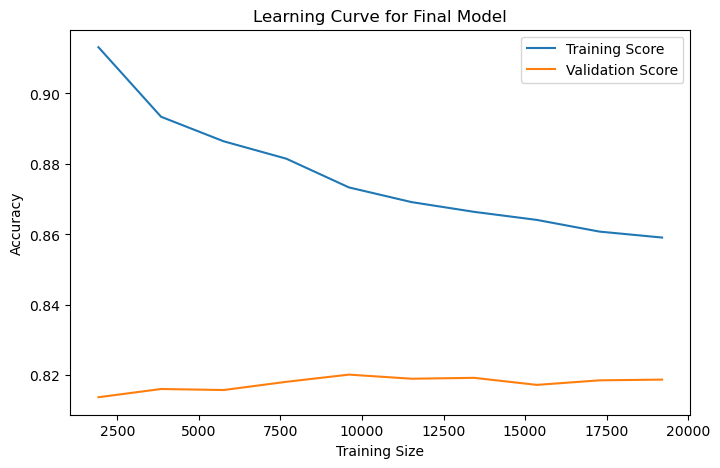

In [68]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

model = cat_model   # or best_xgb or best_rf

train_sizes, train_scores, test_scores = learning_curve(
    model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    train_sizes=np.linspace(0.1,1.0,10)
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(8,5))

plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, test_mean, label="Validation Score")

plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve for Final Model")

plt.legend()
plt.show()

In [ ]:
Does Credit Limit Affect Payment Behavior?

customers with higher defualt credit limits have lower default risk
customers with low credit limits may have higher default probability

because higher limit customers usually have better financial stability and strong credit history